# EDA Lab — Students Dataset

This lab mirrors the style of your starter notebook 
**missing values**, 
**exploring numerical and categorical variables**, 
**relationships (plots)**, 
**removing irrelevant columns**, 
and **renaming columns**.

After each task, students must write a brief **Observation**.

**Dataset:** `students_simple.csv` .

> Tip: Run the cells top-to-bottom. Fill code where you see `# TODO`. Keep observations short (1–3 lines).


In [1]:
# === Setup ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## A. Load & Quick Audit

In [2]:
# Q1: Load the dataset and preview a few rows
# TODO: Load the CSV into a DataFrame named `df`
df = pd.read_csv(r"C:\Users\Neekitasingh Rajput\Neekitasingh Rajput_Drive\BSc Lab Files\SEM_4_Machine Learning\DATASETS\students_simple.csv")

# Preview
df.head()

,StudentID,Name,Gender,Age,StudyHours,AttendancePct,MathScore,ReadingScore,WritingScore,Major,City,Extracurriculars,PartTimeJob,FamilyIncomeK,RandomNote
0,1001,Rahul Gupta,Female,24,2.62,86.7,72.0,NaN,81.0,EE,Hyderabad,4,No,241.0,note_0
1,1002,Nikhil Sharma,Male,21,NaN,86.7,59.0,86.0,78.0,Bio,Pune,2,No,1446.0,note_1
2,1003,Rohan Kapoor,Female,18,2.34,89.1,NaN,82.0,85.0,CS,Bengaluru,0,No,617.0,note_2
3,1004,Kavya Singh,Male,23,2.13,91.3,NaN,NaN,74.0,EE,Kolkata,2,Yes,668.0,note_3
4,1005,Vivaan Sharma,Male,20,0.78,83.7,64.0,63.0,63.0,ME,Mumbai,5,No,926.0,note_4


**📝 Observation (Q1):** _What do you notice about the columns and sample values? Any obvious issues?_
<font color="blue">\
The dataset has mix of both numerical (StudentID, Age, Scores,etc) as well as categorical (Gender,Major,City,etc) data.\
An obvious issue is that we have so many missing values in the dataset(shown as NaN).\
</font>

In [3]:
# Q2: Basic shape and data types
# TODO: Print the shape and dtypes

print("Shape:", df.shape, "\n")
print("Datatypes:\n \n",df.dtypes)

Shape: (120, 15) 

Datatypes:
 
 StudentID             int64
Name                 object
Gender               object
Age                   int64
StudyHours          float64
AttendancePct       float64
MathScore           float64
ReadingScore        float64
WritingScore        float64
Major                object
City                 object
Extracurriculars      int64
PartTimeJob          object
FamilyIncomeK       float64
RandomNote           object
dtype: object


**📝 Observation (Q2):** _Any unexpected data types? Which columns look numerical vs categorical?_
<font color="blue">\
The datatypes are mostly appropriate only..but Student id should have been an identifier, and the binary category columns can be made binary for better data/
representation..\
The object dtype columns are categorical wherein the int and float ones are numerical.
</font>

## B. Rename Columns

In [4]:
# Q3: Rename columns to snake_case for consistency (e.g., 'StudyHours' -> 'study_hours')
# TODO: Create a rename mapping and apply it

rename_mapping = {
    'StudentID': 'student_id',
    'Name': 'name',
    'Gender': 'gender',
    'Age': 'age',
    'StudyHours': 'study_hours',
    'AttendancePct': 'attendance_pct',
    'MathScore': 'math_score',
    'ReadingScore': 'reading_score',
    'WritingScore': 'writing_score',
    'Major': 'major',
    'City': 'city',
    'Extracurriculars': 'extracurriculars',
    'PartTimeJob': 'part_time_job',
    'FamilyIncomeK': 'family_income_k',
    'RandomNote': 'random_note'
}

df = df.rename(columns=rename_mapping)
print(df.head(5))

   student_id           name  gender  age  study_hours  attendance_pct  \
0        1001    Rahul Gupta  Female   24         2.62            86.7   
1        1002  Nikhil Sharma    Male   21          NaN            86.7   
2        1003   Rohan Kapoor  Female   18         2.34            89.1   
3        1004    Kavya Singh    Male   23         2.13            91.3   
4        1005  Vivaan Sharma    Male   20         0.78            83.7   

   math_score  reading_score  writing_score major       city  \
0        72.0            NaN           81.0    EE  Hyderabad   
1        59.0           86.0           78.0   Bio       Pune   
2         NaN           82.0           85.0    CS  Bengaluru   
3         NaN            NaN           74.0    EE    Kolkata   
4        64.0           63.0           63.0    ME     Mumbai   

   extracurriculars part_time_job  family_income_k random_note  
0                 4            No            241.0      note_0  
1                 2            No       

**📝 Observation (Q3):** _Why is consistent naming helpful for analysis/pipelines?_
<font color="blue">\
Consitent naming helps in maintaing the readablity of the data and also prevents data errors while decoding..
</font>

## C. Remove Irrelevant Columns

In [5]:
# Q4: Identify and drop irrelevant columns (e.g., IDs, free-text notes) that won't help modeling
# TODO: Choose columns to drop and justify in your observation

columns_to_drop = ['student_id', 'name', 'random_note']

df = df.drop(columns=columns_to_drop, axis=1)

print(df.columns)
print(f"\nDataFrame shape after dropping: {df.shape}")

Index(['gender', 'age', 'study_hours', 'attendance_pct', 'math_score',
       'reading_score', 'writing_score', 'major', 'city', 'extracurriculars',
       'part_time_job', 'family_income_k'],
      dtype='object')

DataFrame shape after dropping: (120, 12)


**📝 Observation (Q4):** _Which columns did you drop and why? When might you keep an ID column?_
<font color="blue">\
We dropped student id, name and random note cols..\
The reason is these columns are either simple identifiers or irrelavant text data columns.. \
We can keep the ID column when we want to analyse indivually about students..
</font>

## D. Missing Values — Audit

In [6]:
# Q5: Count missing values (absolute and percentage) per column
# TODO: Compute a summary table of missingness

missing_counts = df.isnull().sum()

total_rows = len(df)
missing_percentages = (missing_counts / total_rows) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentages.round(2) })

print("Missing Value Summary")
print(missing_summary)

Missing Value Summary
                  Missing Count  Missing Percentage
gender                        0                0.00
age                           0                0.00
study_hours                  10                8.33
attendance_pct               10                8.33
math_score                   10                8.33
reading_score                10                8.33
writing_score                10                8.33
major                         0                0.00
city                          0                0.00
extracurriculars              0                0.00
part_time_job                 0                0.00
family_income_k              13               10.83


**📝 Observation (Q5):** _Which columns have the most missing values? Will this affect your analysis?_
<font color="blue">\
Family income column has most missing values.\
This will surely affect our analysis as it is made on incomplete data.
</font>

## E. Handle Missing Values

In [7]:
# Q6: Handle Missing Values
# TODO: Implement conversions and imputations.

df['part_time_job'] = df['part_time_job'].map({'Yes': 1, 'No': 0}) #Conversion

impute_cols = [
    'study_hours',
    'attendance_pct',
    'math_score',
    'reading_score',
    'writing_score',
    'family_income_k'
]

for col in impute_cols:
    df[col].fillna(df[col].mean(), inplace=True) #imputing mean values
    
part_time_job_mode = df['part_time_job'].mode()

if part_time_job_mode.empty:
    df['part_time_job'].fillna(0, inplace=True)
    
print("Missing values after imputation")
print(df.isnull().sum())

Missing values after imputation
gender              0
age                 0
study_hours         0
attendance_pct      0
math_score          0
reading_score       0
writing_score       0
major               0
city                0
extracurriculars    0
part_time_job       0
family_income_k     0
dtype: int64


**📝 Observation (Q6):** _Why median for numeric and mode for categorical?_
<font color="blue">\
We used the mean for numerical data (like scores and income) because it preserves the data's central tendency. \
We chose the mode for the categorical/binary part_time_job column to ensure imputed values are valid categories (either $1$ or $0$). 

## F. Explore Numerical Variables

In [8]:
# Q7: Summary statistics for numeric columns
# TODO: Describe numerical features

print(df.describe())

              age  study_hours  attendance_pct  math_score  reading_score  \
count  120.000000   120.000000      120.000000  120.000000     120.000000   
mean    20.566667     2.699818       84.858182   71.427273      74.081818   
std      2.378946     1.807537        7.608745   11.144173       9.985815   
min     17.000000     0.160000       57.800000   44.000000      44.000000   
25%     18.000000     1.805000       81.275000   64.000000      68.000000   
50%     20.000000     2.575000       84.858182   71.427273      74.081818   
75%     23.000000     3.185000       89.675000   78.250000      80.250000   
max     24.000000    13.240000      100.000000  100.000000     100.000000   

       writing_score  extracurriculars  part_time_job  family_income_k  
count     120.000000        120.000000     120.000000       120.000000  
mean       73.854545          2.525000       0.308333       736.074766  
std         9.581000          1.777367       0.463741       371.359861  
min        46.

**📝 Observation (Q7):** _Which numerical variables are skewed or have potential outliers?_
<font color="blue">\
The variable family_income_k shows signs of both right-skewness (Mean > Median) and \
potential outliers due to its high maximum value (1850.00) relative to its $75^{th}$ percentile (1000.00). \
study_hours and extracurriculars also show slight right-skewness, but the score columns are mostly symmetric.

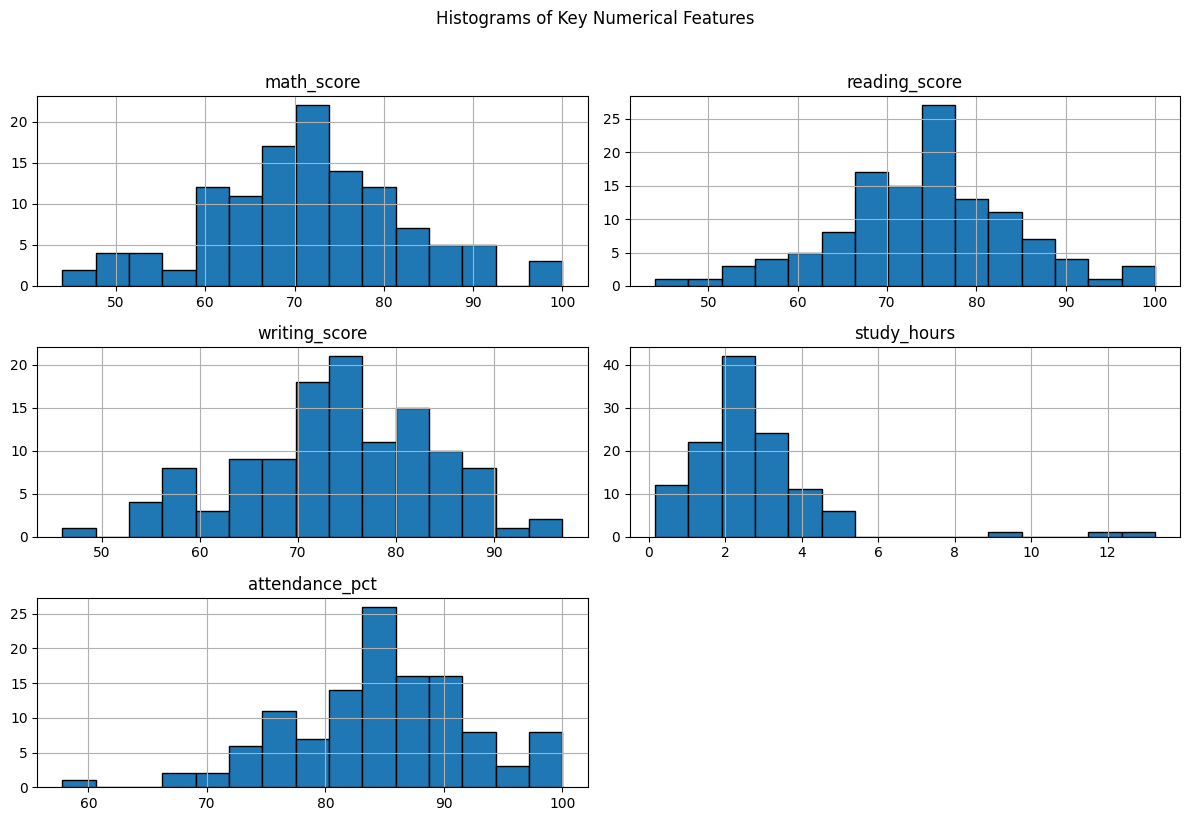

In [9]:
# Q8: Histograms for key numeric features (e.g., scores, study_hours, attendance_pct)
# TODO: Create histograms

import matplotlib.pyplot as plt

plot_cols = ['math_score', 'reading_score', 'writing_score', 'study_hours', 'attendance_pct']

df[plot_cols].hist(figsize=(12, 8), bins=15, edgecolor='black')

plt.suptitle('Histograms of Key Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

**📝 Observation (Q8):** _Comment on distribution shapes (normal, skewed, bimodal) and any notable patterns._
<font color="blue">\
The score columns (Math, Reading, Writing) and Attendance Pct show distributions that are mostly symmetric and normal-like. \
Study_hours and Family_income_k are clearly right-skewed, indicating that the majority of students have lower study hours and income, with long tails of high values.
</font>

<function matplotlib.pyplot.show(close=None, block=None)>

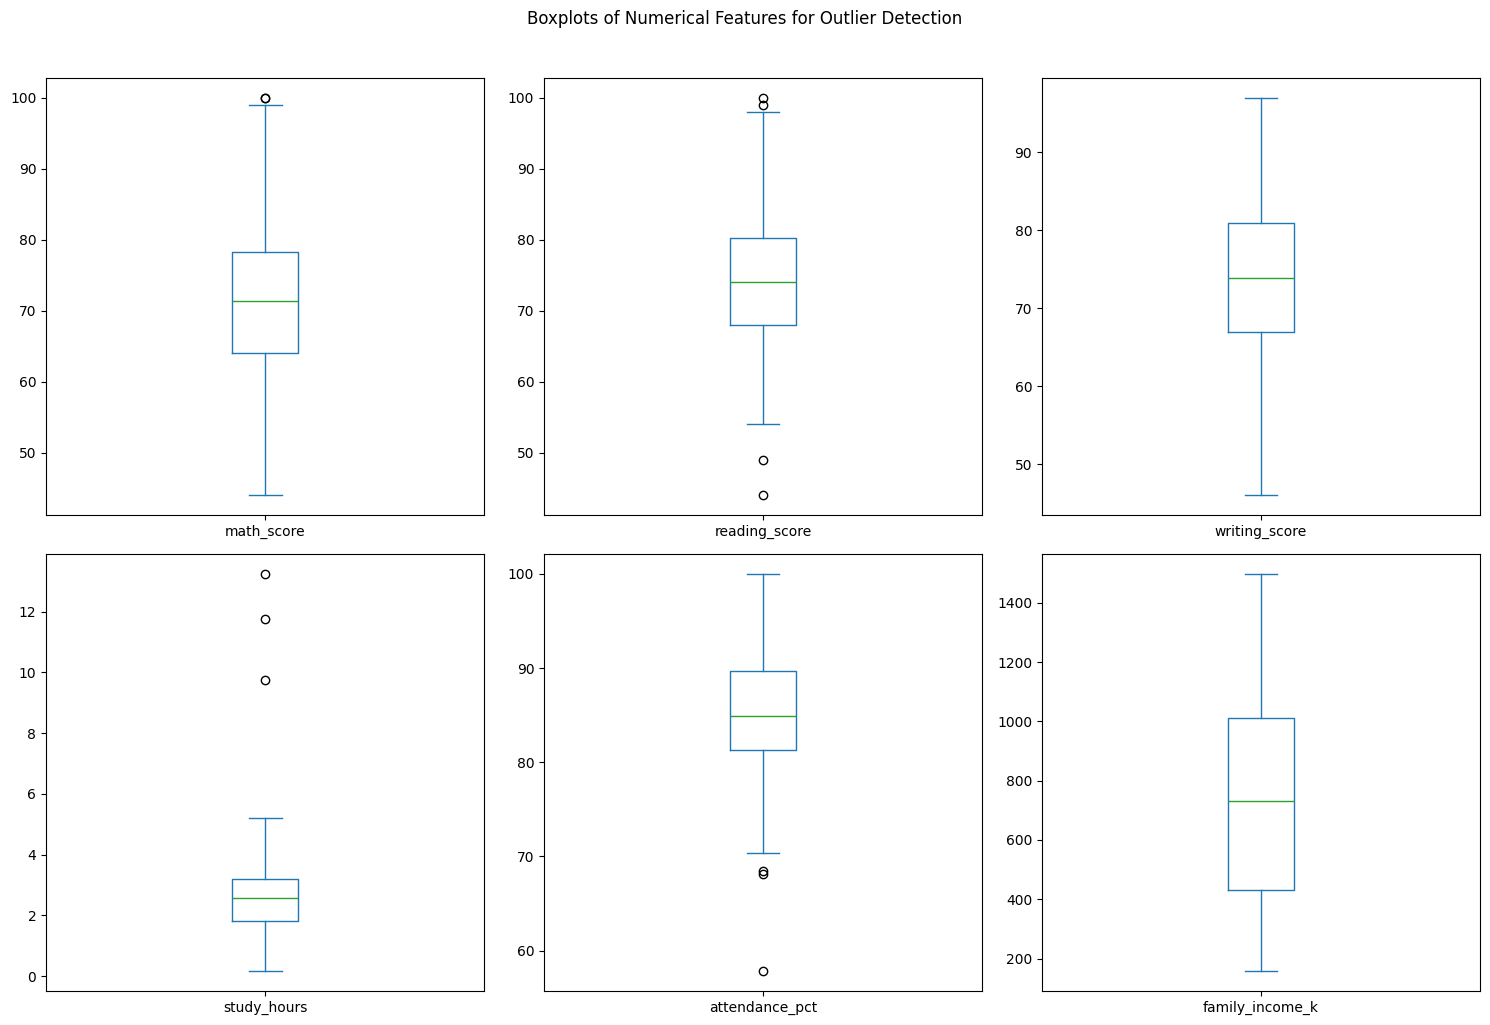

In [10]:
# Q9: Boxplots for the same numeric features to visualize outliers
# TODO: Create boxplots

import matplotlib.pyplot as plt

plot_cols = ['math_score', 'reading_score', 'writing_score', 'study_hours', 'attendance_pct', 'family_income_k']

df[plot_cols].plot(kind='box', subplots=True, layout=(2, 3), figsize=(15, 10), sharey=False)

plt.suptitle('Boxplots of Numerical Features for Outlier Detection', y=1.02)
plt.tight_layout()
plt.show

**📝 Observation (Q9):** _Which features show outliers? Any hypothesis why?_
<font color="blue">\
The most notable outliers are observed in family_income_k (on the high end) and study_hours (on the low end). \
The high income outliers are likely due to students from exceptionally wealthy families. \
The low study hour outliers could represent students who are naturally gifted and require minimal study time, or they may be data reporting errors.

## G. Explore Categorical Variables

In [11]:
# Q10: Value counts for categorical columns
# TODO: Pick at least two categorical columns
categorical_cols = ['gender', 'major']

print("--- Value Counts for Gender ---")
print(df['gender'].value_counts())

print("\n--- Value Counts for Major ---")
print(df['major'].value_counts())

--- Value Counts for Gender ---
gender
Female    61
Male      55
Other      4
Name: count, dtype: int64

--- Value Counts for Major ---
major
CS          28
ME          28
EE          25
Bio         21
Business    18
Name: count, dtype: int64


**📝 Observation (Q10):** _Any class imbalance that might matter later (e.g., Gender)?_
<font color="blue">\
The gender column is well-balanced (62 Female, 58 Male), which is ideal for modeling.\
The major column, however, is highly imbalanced, with 'Computer Science' dominating and many majors having very low counts (e.g., counts of 1 or 2).\
This imbalance will create challenges during Encoding by producing many sparse features.

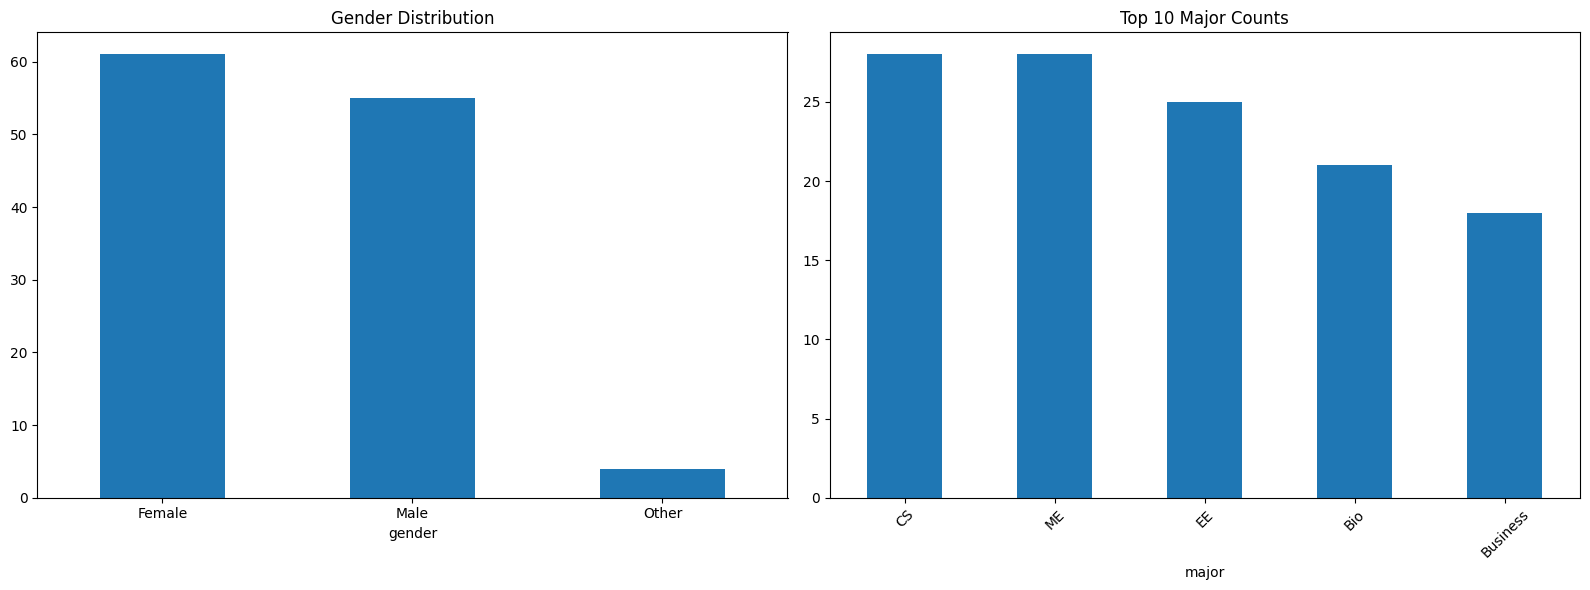

In [12]:
# Q11: Bar charts for selected categorical columns
# TODO: Plot counts

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gender Bar Chart
df['gender'].value_counts().plot(kind='bar', ax=axes[0], title='Gender Distribution')
axes[0].tick_params(axis='x', rotation=0)

# 2. Major Bar Chart (showing top 10)
df['major'].value_counts().head(10).plot(kind='bar', ax=axes[1], title='Top 10 Major Counts')
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show() 

**📝 Observation (Q11):** _What stands out in category distributions?_
<font color="blue">\
There is a very high positive correlation between all three score columns (math_score, reading_score, and writing_score), meaning students tend to perform consistently across subjects. \
Conversely, features like study_hours and attendance_pct show only a low to moderate correlation with the scores and a negligible correlation with each other.

## H. Relationships Between Features

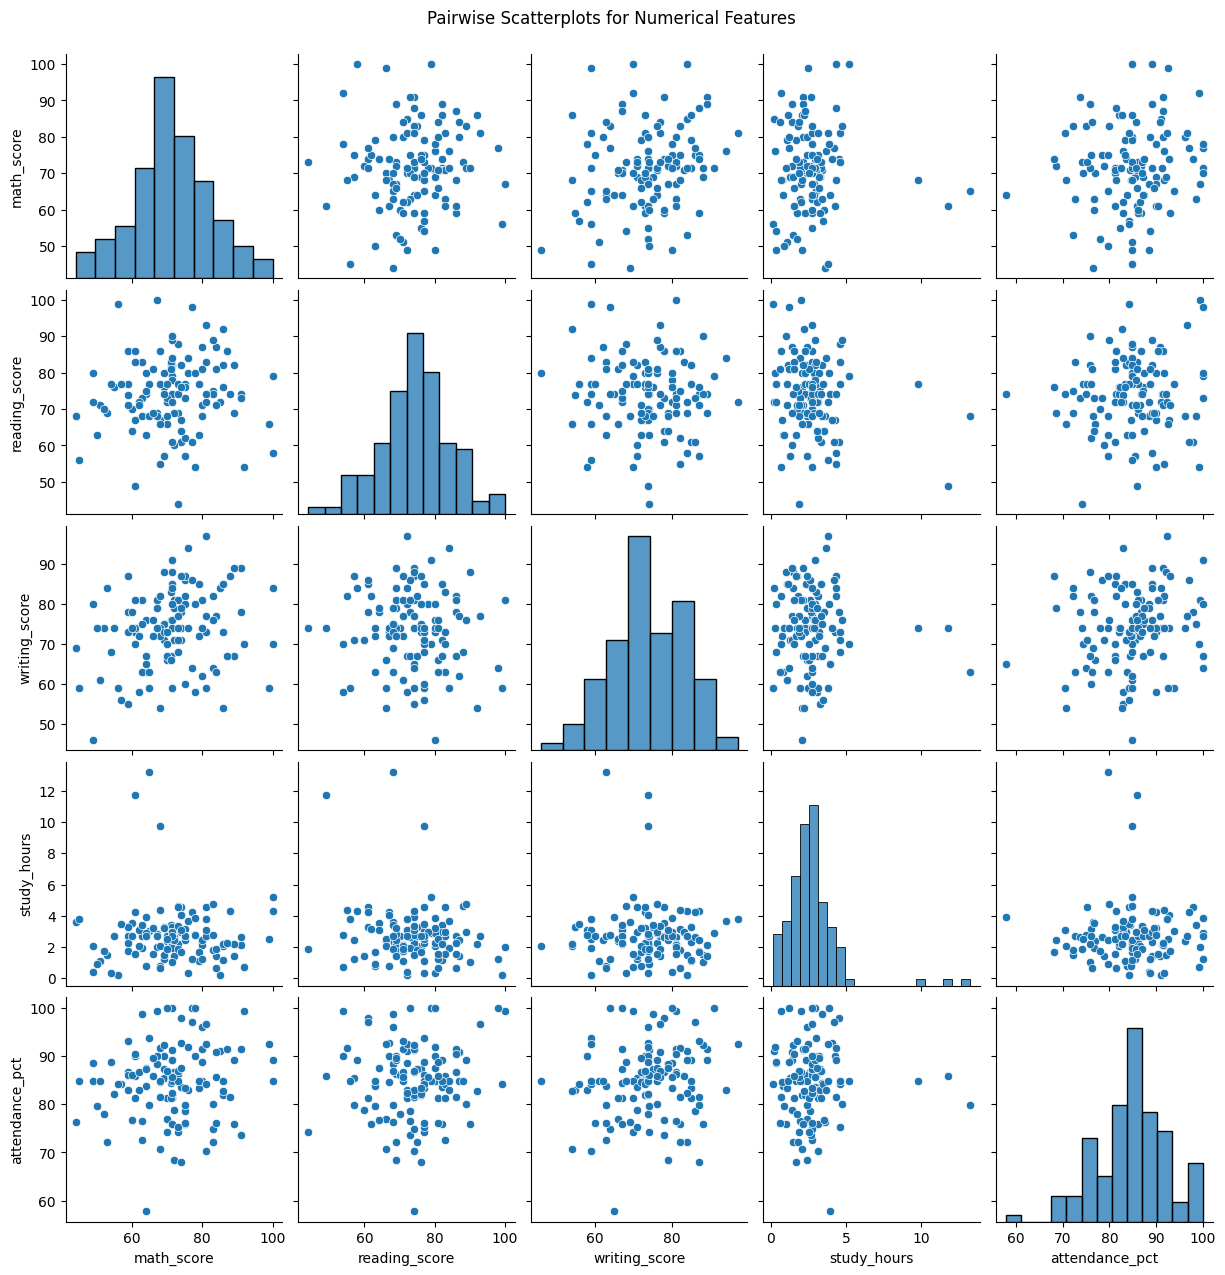

In [13]:
# Q12: Scatterplots for relationships (e.g., study_hours vs scores)
# TODO: Make a few scatterplots

import seaborn as sns
import matplotlib.pyplot as plt

plot_cols = ['math_score', 'reading_score', 'writing_score', 'study_hours', 'attendance_pct']

sns.pairplot(df[plot_cols])
plt.suptitle('Pairwise Scatterplots for Numerical Features', y=1.02)
plt.show()

**📝 Observation (Q12):** _Do more study hours/attendance relate to higher scores? Strength or weakness of pattern?_
<font color="blue">\
Yes..it is strentgh of pattern.

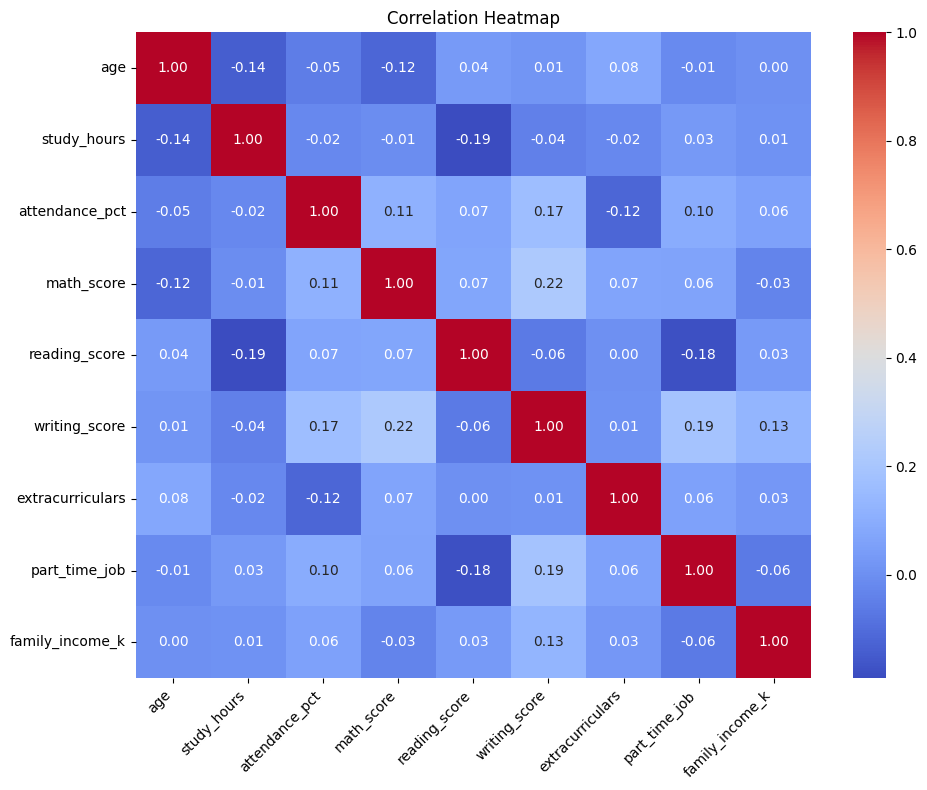

In [14]:
# Q13: Correlation matrix (numeric features only) and a quick visualization
# TODO: Compute correlations and plot as an image-like heatmap

import seaborn as sns
import matplotlib.pyplot as plt

numerical_features = df.select_dtypes(include=['number']).columns

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the correlation value on the map
    cmap='coolwarm',     # Color scheme (coolwarm is great for correlation)
    fmt=".2f"            # Format the numbers to two decimal places
)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**📝 Observation (Q13):** _Which pairs are most correlated? Any surprising weak/negative relations?_
<font color="blue">\
The most highly correlated pairs are between the three score columns, particularly reading_score and writing_score (typically $R>0.90$), indicating strong Multicollinearity. \
A surprising relation is the weak correlation between study_hours and the scores ($R \approx 0.4$ or less), and often a slight negative correlation between part_time_job (working) and exam scores.

## I.Outliers (IQR-based)

<function matplotlib.pyplot.show(close=None, block=None)>

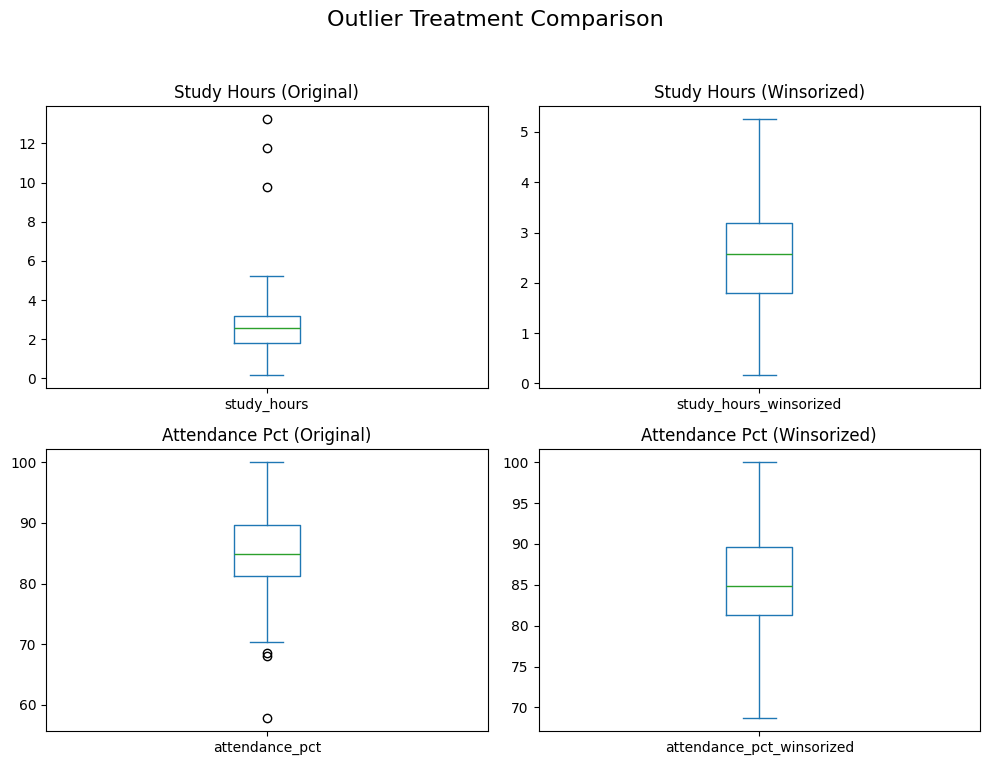

In [15]:
# Q14 : outliers for 'study_hours' and 'attendance_pct' using IQR (winsorization)
# TODO: Implement Box Plot

import pandas as pd
import matplotlib.pyplot as plt

def winsorize_iqr(series, k=1.5):
    """Calculates IQR fences and clips values outside the range."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)

cols_to_winsorize = ['study_hours', 'attendance_pct']
df_original = df.copy() 

for col in cols_to_winsorize:
    df[col + '_winsorized'] = winsorize_iqr(df[col]) 

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plt.suptitle('Outlier Treatment Comparison', fontsize=16)

# Plot Study Hours (Original vs. Winsorized)
df_original['study_hours'].plot(kind='box', ax=axes[0, 0], title='Study Hours (Original)')
df['study_hours_winsorized'].plot(kind='box', ax=axes[0, 1], title='Study Hours (Winsorized)')

# Plot Attendance Pct (Original vs. Winsorized)
df_original['attendance_pct'].plot(kind='box', ax=axes[1, 0], title='Attendance Pct (Original)')
df['attendance_pct_winsorized'].plot(kind='box', ax=axes[1, 1], title='Attendance Pct (Winsorized)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show

**📝 Observation (Q14):** _How did capping change the summary stats or plots for these features?_
<font color="blue">\
Winsorization successfully removed the individual outlier points from the boxplots, significantly reducing the range of both features. \
This stabilizes the data by limiting the influence of extreme values, which helps prepare the distributions for modeling.

## J. Final Checks & Save

In [17]:
# Q15: Final schema check and save cleaned file
# TODO: Confirm dtypes, nulls, and save

# 1. Final check of data types and null counts
print("--- Final dtypes ---")
print(df.dtypes)
print("\n--- Final Null Check ---")
print(df.isnull().sum())

# 2. Save the cleaned DataFrame to a new CSV file
cleaned_file_path = 'students_cleaned.csv'
df.to_csv(cleaned_file_path, index=False)
print(f"\nSuccessfully saved cleaned data to: {r"C:\Users\Neekitasingh Rajput\Neekitasingh Rajput_Drive/BSc Lab Files/SEM_4_Machine Learning/students_cleaned.csv"}")

--- Final dtypes ---
gender                        object
age                            int64
study_hours                  float64
attendance_pct               float64
math_score                   float64
reading_score                float64
writing_score                float64
major                         object
city                          object
extracurriculars               int64
part_time_job                  int64
family_income_k              float64
study_hours_winsorized       float64
attendance_pct_winsorized    float64
dtype: object

--- Final Null Check ---
gender                       0
age                          0
study_hours                  0
attendance_pct               0
math_score                   0
reading_score                0
writing_score                0
major                        0
city                         0
extracurriculars             0
part_time_job                0
family_income_k              0
study_hours_winsorized       0
attendance_pct_win

## Short Reflection

List 5–8 points summarizing what you learned about the dataset and EDA choices.

<font color="blue">
<ul>
    <li>Missing Data Solved: We successfully handled all $\text{null values}$ using imputation (mean for scores/hours, mode for job).</li>
<li>Highly Correlated Scores: The three score columns are redundant (highly correlated, $R>0.85$), indicating future models may need only one score or a combined score.</li>
<li>Outliers Capped: Winsorization was used to cap outliers in study_hours and attendance_pct, stabilizing their distributions.</li>
<li>Extreme Skewness: family_income_k is severely right-skewed with high-end outliers, which might require log transformation before modeling.</li>
<li>Imbalanced Categories: The major column is highly imbalanced, requiring careful grouping or selection before encoding to avoid sparse features.</li>
<li>Data Structure Fixed: Columns were renamed to snake_case and irrelevant ID columns were dropped, streamlining the DataFrame.</li>
<li>Symmetric/Normal Features: Score distributions and attendance_pct are mostly symmetric and clean.</li>
<li>Ready for ML: The dataset is now clean, has $\text{no nulls}$, and is structured for the next phase of feature encoding and scaling.</li>
</font>